## The goal: to have more analysis and understanding on the 2000 + schools that are within a mile of a superfund site. 

In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path('..') 
DATA = ROOT / 'all_datasets' / 'schools_and_superfund'

df = pd.read_csv(DATA / 'schools_and_superfund.csv')
df

,NAME,Site_Name,distance_to_site_miles,ZIP,STATE,CITY
0,LONGFELLOW ELEMENTARY,Fruit Avenue Plume,0.045738,87102,NM,ALBUQUERQUE
1,Insight School of WA Open Doors Program,"Commencement Bay, South Tacoma Channel",0.050809,98409,WA,Tacoma
2,Basin School,Basin Mining Area,0.059319,59631,MT,Basin
3,Van Cleve Elementary School,East Troy Contaminated Aquifer,0.066303,45373,OH,Troy
4,North Belmont Elementary,North Belmont PCE,0.068183,28012,NC,Belmont
...,...,...,...,...,...,...
2055,GREEN PINES ELEM.,Ellisville Site,0.997433,63011,MO,WILDWOOD
2056,Cordova High School,National Fireworks,0.998665,38016,TN,Cordova
2057,Owen Valley Middle School,Franklin Street Groundwater Contamination,0.998830,47460,IN,Spencer
2058,SULLIVAN ELEM.,Oak Grove Village Well,0.998947,63080,MO,SULLIVAN


## I want to see the median income for the schools near superfund sites. 

In [52]:
from dotenv import load_dotenv
load_dotenv() 

True

In [53]:
%%R 
census_api_key(Sys.getenv("CENSUS_API_KEY"))

To install your API key for use in future sessions, run this function with `install = TRUE`.


In [54]:
%%R 

Sys.getenv("CENSUS_API_KEY")


[1] ""


In [61]:
%%R 

library(readr)

df <- read_csv("../all_datasets/schools_and_superfund/schools_and_superfund.csv")

df <- df %>%
  mutate(
    CNTY = stringr::str_pad(as.character(CNTY), width = 5, pad = "0")
  )
df


Rows: 2060 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): NAME, Site_Name, STATE, CITY
dbl (3): distance_to_site_miles, ZIP, CNTY

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 2,060 × 7
   NAME                 Site_Name distance_to_site_miles   ZIP STATE CITY   CNTY
   <chr>                <chr>                      <dbl> <dbl> <chr> <chr> <dbl>
 1 LONGFELLOW ELEMENTA… Fruit Av…                 0.0457 87102 NM    ALBU… 35001
 2 Insight School of W… Commence…                 0.0508 98409 WA    Taco… 53053
 3 Basin School         Basin Mi…                 0.0593 59631 MT    Basin 30043
 4 Van Cleve Elementar… East Tro…                 0.0663 45373 OH    Troy  39109
 5 North Belmont Eleme… North Be…                 0.0682 28012 NC    Belm… 37071
 6 INES MARIA MENDOZA … Cabo Roj…                 0.0697 

## Convert CNTY data to a character. 

In [62]:
%%R
library(stringr)

df <- df %>%
  mutate(
    CNTY = str_pad(as.character(CNTY), width = 5, pad = "0")
  )


## Get median income data from census. 

In [63]:
%%R
# Pull ACS 2021 5-year data for median household income at county level
county_income <- get_acs(
  geography = "county",
  variables = c(med_inc = "B19013_001"), # median household income
  year = 2021,
  survey = "acs5",
  geometry = FALSE
) %>%
  select(GEOID, med_inc = estimate)

# Check first few rows
head(county_income)


# A tibble: 6 × 2
  GEOID med_inc
  <chr>   <dbl>
1 01001   62660
2 01003   64346
3 01005   36422
4 01007   54277
5 01009   52830
6 01011   29063


Getting data from the 2017-2021 5-year ACS


## Join county-level median income to the schools&superfund sites dataset. 

In [64]:
%%R

schools_with_income <- df %>%
  left_join(county_income, by = c("CNTY" = "GEOID"))

# Quick check for missing values
pct_missing <- mean(is.na(schools_with_income$med_inc)) * 100
print(paste0("Percent of schools missing income: ", round(pct_missing, 1), "%"))

# View first rows
head(schools_with_income)

[1] "Percent of schools missing income: 1%"
# A tibble: 6 × 8
  NAME          Site_Name distance_to_site_miles   ZIP STATE CITY  CNTY  med_inc
  <chr>         <chr>                      <dbl> <dbl> <chr> <chr> <chr>   <dbl>
1 LONGFELLOW E… Fruit Av…                 0.0457 87102 NM    ALBU… 35001   56920
2 Insight Scho… Commence…                 0.0508 98409 WA    Taco… 53053   82574
3 Basin School  Basin Mi…                 0.0593 59631 MT    Basin 30043   72500
4 Van Cleve El… East Tro…                 0.0663 45373 OH    Troy  39109   66284
5 North Belmon… North Be…                 0.0682 28012 NC    Belm… 37071   56819
6 INES MARIA M… Cabo Roj…                 0.0697   623 PR    CABO… 72023   18581


In [68]:
%%R
state_thresholds <- county_income %>%
  mutate(state_fips = substr(GEOID, 1, 2)) %>%  
  group_by(state_fips) %>%
  summarise(
    p25 = quantile(med_inc, 0.25, na.rm = TRUE),
    p50 = quantile(med_inc, 0.50, na.rm = TRUE),
    state_median = median(med_inc, na.rm = TRUE),
    n_counties = n()
  )

print(state_thresholds)

schools_with_income <- schools_with_income %>%
  mutate(state_fips = substr(CNTY, 1, 2)) %>%
  left_join(state_thresholds, by = "state_fips") %>%
  mutate(
    low_income_county = ifelse(med_inc < p25, 1, 0),
    low_income_county = ifelse(is.na(med_inc), NA, low_income_county)
  )

state_summary <- schools_with_income %>%
  group_by(state_fips) %>%
  summarise(
    total_schools = n(),
    schools_in_low_income = sum(low_income_county == 1, na.rm = TRUE),
    pct_in_low_income = mean(low_income_county == 1, na.rm = TRUE) * 100
  ) %>%
  arrange(desc(pct_in_low_income))

print(state_summary)

# A tibble: 52 × 5
   state_fips    p25    p50 state_median n_counties
   <chr>       <dbl>  <dbl>        <dbl>      <int>
 1 01         43214. 46186        46186          67
 2 02         62425  71890.       71890.         30
 3 04         47932  55077        55077          15
 4 05         41076. 45318        45318          75
 5 06         58833. 70037        70037          58
 6 08         49818. 61672.       61672.         64
 7 09         78041. 82558.       82558.          8
 8 10         66300. 68886        68886           3
 9 11         93547  93547        93547           1
10 12         46958. 56786        56786          67
# ℹ 42 more rows
# ℹ Use `print(n = ...)` to see more rows
# A tibble: 49 × 4
   state_fips total_schools schools_in_low_income pct_in_low_income
   <chr>              <int>                 <int>             <dbl>
 1 16                     1                     1             100  
 2 44                     8                     5              62.5
 3 19  

## Now, let's print out how many schools are considered low-income county schools. 

In [70]:
%%R

summary_stats <- schools_with_income %>%
  summarise(
    total = n(),
    low_income = sum(low_income_county == 1, na.rm = TRUE),
    pct = mean(low_income_county == 1, na.rm = TRUE) * 100,
    missing = sum(is.na(low_income_county))
  )

cat(sprintf("Total Schools:              %s\n", 
            format(summary_stats$total, big.mark = ",")))
cat(sprintf("Low-Income County Schools:  %s\n", 
            format(summary_stats$low_income, big.mark = ",")))
cat(sprintf("Percentage Low-Income:      %.1f%%\n", 
            summary_stats$pct))
cat(sprintf("Missing Data:               %s\n", 
            format(summary_stats$missing, big.mark = ",")))


Total Schools:              2,060
Low-Income County Schools:  220
Percentage Low-Income:      10.8%
Missing Data:               20


## Let's visualize this finding

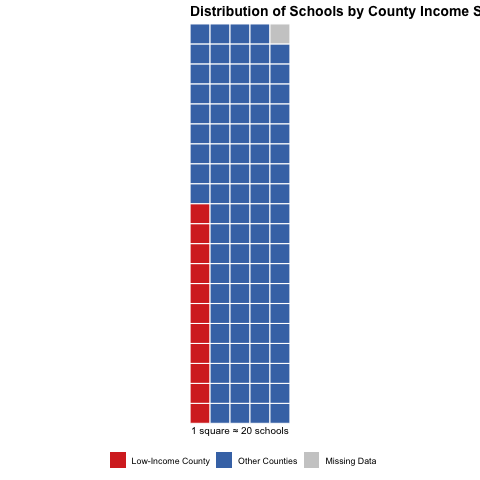

In [72]:
%%R
library(waffle)
library(ggplot2)

waffle_data <- c(
  "Low-Income County" = 11,  
  "Other Counties" = 88,    
  "Missing Data" = 1        
)


waffle(
  waffle_data,
  rows = 20,
  size = 0.5,
  colors = c("#d73027", "#4575b4", "#cccccc"),
  title = "Distribution of Schools by County Income Status",
  xlab = "1 square ≈ 20 schools"
) +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    legend.position = "bottom"
  )

In [82]:
%%R 
ggsave(
  filename = "../assets/svg/schools_waffle.svg",
  plot = last_plot(),
  device = "svg",
  width = 7,
  height = 5,
  units = "in"
)

## Create a beeswarm chart showing how close schools are to a superfund site. (distribution is the miles) 

In [57]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [59]:
%%R 

library(readr)

df <- read_csv("../all_datasets/schools_and_superfund/schools_and_superfund.csv")

df


Rows: 2060 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): NAME, Site_Name, STATE, CITY
dbl (3): distance_to_site_miles, ZIP, CNTY

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 2,060 × 7
   NAME                 Site_Name distance_to_site_miles   ZIP STATE CITY   CNTY
   <chr>                <chr>                      <dbl> <dbl> <chr> <chr> <dbl>
 1 LONGFELLOW ELEMENTA… Fruit Av…                 0.0457 87102 NM    ALBU… 35001
 2 Insight School of W… Commence…                 0.0508 98409 WA    Taco… 53053
 3 Basin School         Basin Mi…                 0.0593 59631 MT    Basin 30043
 4 Van Cleve Elementar… East Tro…                 0.0663 45373 OH    Troy  39109
 5 North Belmont Eleme… North Be…                 0.0682 28012 NC    Belm… 37071
 6 INES MARIA MENDOZA … Cabo Roj…                 0.0697 

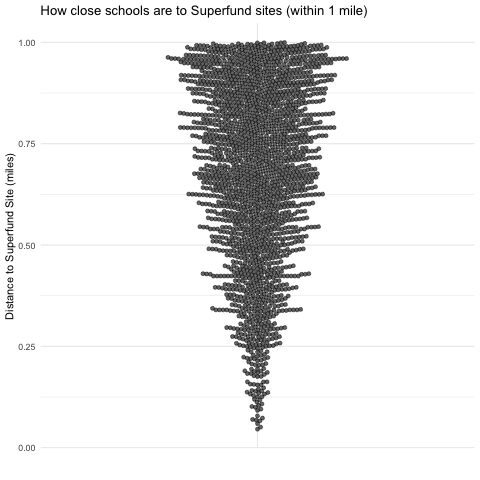

In [15]:
%%R 
library(ggplot2)
library(ggbeeswarm)
library(tidycensus)
library(tidyverse)
ggplot(df, aes(
  x = "",
  y = distance_to_site_miles
)) +
  geom_beeswarm(
    size = 1.5,
    alpha = 0.6
  ) +
  theme_minimal() +
  labs(
    title = "How close schools are to Superfund sites (within 1 mile)",
    x = "",
    y = "Distance to Superfund Site (miles)"
  )

In [83]:
%%R 
ggsave(
  filename = "../assets/svg/schools_beeswarm.svg",
  plot = last_plot(),
  device = "svg",
  width = 7,
  height = 5,
  units = "in"
)